In [43]:
from fetch_stock_data import collect_data, get_eval_stocks, collect_eval_data
from stock_model_trainer import create_sequences, ModelTrainer, train_eval
from stock_predictor_models import CustomMinMaxScaler, StockLSTM, StockTransformer
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from itertools import cycle

# Train

In [44]:
preds_df, results, model, scaler = train_eval(
    StockTransformer, 
    kwargs=dict(hidden_dim=8), 
    epochs=100, 
    train_fig_path="transformer_losses.png",
    eval_fig_path="transformer_eval.png",
)

/Users/williamlusty/Documents/GitHub/CS7643-Final-Project/fetch_stock_data.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start=start_date, end=end_date, interval=freq)
[*********************100%***********************]  5 of 5 completed
/Users/williamlusty/Documents/GitHub/CS7643-Final-Project/fetch_stock_data.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start=start_date, end=end_date, interval=freq)
[*********************100%***********************]  5 of 5 completed


Epoch [5/100], Loss: 0.184384
Epoch [10/100], Loss: 0.116030
Epoch [15/100], Loss: 0.106733
Epoch [20/100], Loss: 0.092315
Epoch [25/100], Loss: 0.082491
Epoch [30/100], Loss: 0.079071
Epoch [35/100], Loss: 0.077161
Epoch [40/100], Loss: 0.073744
Epoch [45/100], Loss: 0.069803
Epoch [50/100], Loss: 0.067298
Epoch [55/100], Loss: 0.063638
Epoch [60/100], Loss: 0.059670
Epoch [65/100], Loss: 0.055725
Epoch [70/100], Loss: 0.050912
Epoch [75/100], Loss: 0.045441
Epoch [80/100], Loss: 0.041410
Epoch [85/100], Loss: 0.037630
Epoch [90/100], Loss: 0.035054
Epoch [95/100], Loss: 0.032996
Epoch [100/100], Loss: 0.030532


/Users/williamlusty/Documents/GitHub/CS7643-Final-Project/fetch_stock_data.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start=start_date, end=end_date, interval=freq)
[*********************100%***********************]  5 of 5 completed


<Figure size 640x480 with 0 Axes>

In [45]:
results

{'per_stock_mse': {'AAPL_MSE': 1007.5410671185666,
  'JPM_MSE': 2946.7340082947817,
  'XOM_MSE': 3484.7241135653844,
  'BA_MSE': 73945.44831213792,
  'UNH_MSE': 128809.15830288813},
 'per_stock_smape': {'AAPL_MSE': 11.829193275230944,
  'JPM_MSE': 18.81124797743307,
  'XOM_MSE': 42.798835950680946,
  'BA_MSE': 82.98319280229323,
  'UNH_MSE': 137.65085212906297},
 'average_smape': 58.814664426940226}

# Plot

In [46]:
eval_truth = collect_eval_data()

/Users/williamlusty/Documents/GitHub/CS7643-Final-Project/fetch_stock_data.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start=start_date, end=end_date, interval=freq)
[*********************100%***********************]  5 of 5 completed


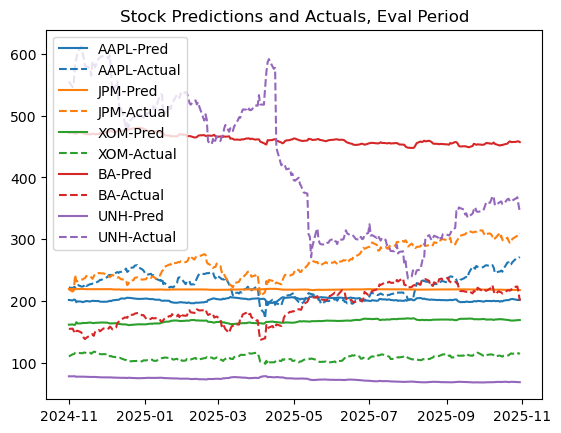

In [47]:
# Get the default matplotlib color cycle
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])
for stock in get_eval_stocks():
    # Ask matplotlib for the next default color
    color = next(color_cycle)
    plt.plot(preds_df[stock], label=f"{stock}-Pred", color=color)
    plt.plot(eval_truth[stock], label=f"{stock}-Actual", color=color, linestyle="--")
plt.legend()
plt.title("Stock Predictions and Actuals, Eval Period")
plt.show()

In [48]:
model

StockTransformer(
  (input_proj): Linear(in_features=5, out_features=8, bias=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=8, out_features=8, bias=True)
        )
        (linear1): Linear(in_features=8, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=8, bias=True)
        (norm1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc_out): Linear(in_features=8, out_features=5, bias=True)
)

In [49]:
data = collect_data(get_eval_stocks(), "2024-09-01", "2025-10-31")
prices = torch.tensor(data.values, dtype=torch.float32)
X_seq, y_seq = create_sequences(prices, seq_length=60)

/Users/williamlusty/Documents/GitHub/CS7643-Final-Project/fetch_stock_data.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(symbols, start=start_date, end=end_date, interval=freq)
[*********************100%***********************]  5 of 5 completed


In [50]:
X_seq_scaled = scaler.transform(X_seq)
y_seq_scaled = scaler.transform(y_seq)

In [51]:
model.eval()
with torch.no_grad():
    preds_scaled = model(X_seq_scaled)

In [52]:
X_seq_scaled[0]

tensor([[0.9365, 0.1969, 0.9644, 0.9830, 0.9011],
        [0.9276, 0.2034, 0.9592, 0.9935, 0.8871],
        [0.9346, 0.2002, 0.9500, 0.9769, 0.8782],
        [0.9274, 0.1867, 0.9221, 0.9796, 0.8729],
        [0.9278, 0.2025, 0.9456, 0.9742, 0.8965],
        [0.9241, 0.1940, 0.8848, 0.9837, 0.8547],
        [0.9359, 0.1978, 0.8938, 0.9659, 0.8437],
        [0.9365, 0.2021, 0.8904, 0.9634, 0.8588],
        [0.9352, 0.1842, 0.8781, 0.9747, 0.8580],
        [0.9066, 0.1806, 0.8972, 0.9687, 0.8736],
        [0.9087, 0.1831, 0.9047, 0.9472, 0.8882],
        [0.9268, 0.1792, 0.8955, 0.9524, 0.8922],
        [0.9647, 0.1777, 0.9114, 0.9455, 0.9064],
        [0.9616, 0.1738, 0.9147, 0.9416, 0.8991],
        [0.9536, 0.1828, 0.9166, 0.9385, 0.9200],
        [0.9578, 0.1813, 0.9174, 0.9419, 0.9169],
        [0.9531, 0.1706, 0.9098, 0.9441, 0.8941],
        [0.9585, 0.1777, 0.9076, 0.9412, 0.8745],
        [0.9597, 0.1829, 0.9115, 0.9547, 0.9046],
        [0.9839, 0.1701, 0.9134, 0.9602, 0.9186],


In [53]:
preds_scaled[0]

tensor([0.8303, 0.3696, 0.6900, 0.7628, 0.5438])

In [54]:
y_seq_scaled[0]

tensor([0.9946, 0.1663, 1.1330, 1.0027, 0.9358])